# Benchmarks by Problem Class

This notebook systematically benchmarks discopt against standard solvers for each problem class. For each class we:
1. Generate random problems of increasing size
2. Measure median-of-3 solve time
3. Verify solution accuracy
4. Visualize scaling behavior

LP comparisons use HiGHS {cite:p}`Huangfu2018` and scipy's linprog. The LP IPM uses a Mehrotra predictor-corrector {cite:p}`Mehrotra1992`. MILP uses Branch & Bound {cite:p}`Land1960` with LP relaxations. NLP uses interior-point methods {cite:p}`Nocedal2006`.

| Class | discopt Solver | Comparison Solvers | Sizes |
|-------|---------------|-------------------|-------|
| LP | LP IPM (auto) | HiGHS, scipy linprog | n=5,10,20,50,100 |
| QP | QP IPM (auto) | scipy SLSQP | n=5,10,20,50,100 |
| MILP | B&B + LP (auto) | HiGHS MIP | 5-30 vars |
| MIQP | B&B + QP (auto) | Forced NLP path | 5-12 vars |
| NLP | IPM / Ipopt | 3 backends compared | 2-20 vars |
| MINLP | B&B + NLP | batch_size comparison | 5-12 vars |

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import time
import warnings

import discopt.modeling as dm
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog, minimize

warnings.filterwarnings("ignore")


def median_time(fn, n_trials=3):
    """Run fn n_trials times, return (median_time, last_result)."""
    times = []
    result = None
    for _ in range(n_trials):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)
    return np.median(times), result


print("Setup complete")

Setup complete


## 1. LP Benchmarks

Random LP: min c'x s.t. Ax <= b, x >= 0. We compare discopt's auto-detected LP IPM {cite:p}`Mehrotra1992` against HiGHS {cite:p}`Huangfu2018` (simplex) and scipy's linprog.

In [2]:
from discopt.solvers.lp_highs import solve_lp as highs_solve_lp

lp_sizes = [5, 10, 20, 50, 100]
lp_results = {"discopt": [], "highs": [], "scipy": []}

for n in lp_sizes:
    rng = np.random.RandomState(42 + n)
    m_cons = max(n // 2, 3)

    c_vec = rng.randn(n)
    A_mat = rng.randn(m_cons, n)
    b_vec = np.abs(A_mat @ np.ones(n)) + 1.0

    # --- discopt ---
    def run_discopt():
        m = dm.Model("lp_bench")
        x = m.continuous("x", shape=(n,), lb=0, ub=100)
        m.minimize(dm.sum(lambda i: c_vec[i] * x[i], over=range(n)))
        for k in range(m_cons):
            m.subject_to(dm.sum(lambda i: A_mat[k, i] * x[i], over=range(n)) <= b_vec[k])
        return m.solve()

    t_disc, r_disc = median_time(run_discopt)
    lp_results["discopt"].append(t_disc)

    # --- HiGHS ---
    bounds = [(0, 100)] * n
    t_highs, r_highs = median_time(
        lambda: highs_solve_lp(c_vec, A_ub=A_mat, b_ub=b_vec, bounds=bounds)
    )
    lp_results["highs"].append(t_highs)

    # --- scipy ---
    scipy_bounds = [(0, 100)] * n
    t_scipy, r_scipy = median_time(
        lambda: linprog(c_vec, A_ub=A_mat, b_ub=b_vec, bounds=scipy_bounds)
    )
    lp_results["scipy"].append(t_scipy)

    obj_disc = r_disc.objective if r_disc.objective is not None else float("nan")
    obj_highs = r_highs.objective if r_highs.objective is not None else float("nan")
    obj_scipy = r_scipy.fun if hasattr(r_scipy, "fun") else float("nan")
    print(
        f"n={n:3d} | discopt: {t_disc:.4f}s (obj={obj_disc:.4f}) | "
        f"HiGHS: {t_highs:.4f}s (obj={obj_highs:.4f}) | "
        f"scipy: {t_scipy:.4f}s (obj={obj_scipy:.4f})"
    )

n=  5 | discopt: 0.0045s (obj=-121.2780) | HiGHS: 0.0002s (obj=-121.2780) | scipy: 0.0004s (obj=-121.2780)
n= 10 | discopt: 0.0009s (obj=-20.5493) | HiGHS: 0.0002s (obj=-20.5493) | scipy: 0.0004s (obj=-20.5493)


n= 20 | discopt: 0.0016s (obj=-357.2774) | HiGHS: 0.0002s (obj=-357.2774) | scipy: 0.0005s (obj=-357.2774)
n= 50 | discopt: 0.0059s (obj=-1694.1677) | HiGHS: 0.0006s (obj=-1694.1677) | scipy: 0.0008s (obj=-1694.1677)


n=100 | discopt: 0.0499s (obj=-2262.3757) | HiGHS: 0.0015s (obj=-2262.3760) | scipy: 0.0017s (obj=-2262.3760)


## 2. QP Benchmarks

Random QP: min 0.5 x'Qx + c'x s.t. sum(x) = 1, x >= 0 (portfolio-like). Compare discopt's QP IPM against scipy SLSQP.

In [3]:
qp_sizes = [5, 10, 20, 50, 100]
qp_results = {"discopt": [], "scipy": []}

for n in qp_sizes:
    rng = np.random.RandomState(42 + n)
    # Random PSD matrix for covariance
    L = rng.randn(n, n) * 0.1
    Q = L.T @ L + 0.01 * np.eye(n)
    c_vec = rng.randn(n) * 0.01

    # --- discopt ---
    def run_discopt_qp():
        m = dm.Model("qp_bench")
        x = m.continuous("x", shape=(n,), lb=0, ub=1)
        obj = dm.sum(
            lambda i: dm.sum(lambda j: 0.5 * Q[i, j] * x[i] * x[j], over=range(n)), over=range(n)
        )
        obj = obj + dm.sum(lambda i: c_vec[i] * x[i], over=range(n))
        m.minimize(obj)
        m.subject_to(dm.sum(x) == 1)
        return m.solve()

    t_disc, r_disc = median_time(run_discopt_qp)
    qp_results["discopt"].append(t_disc)

    # --- scipy SLSQP ---
    def run_scipy_qp():
        def obj_fn(x):
            return 0.5 * x @ Q @ x + c_vec @ x

        x0 = np.ones(n) / n
        cons = {"type": "eq", "fun": lambda x: np.sum(x) - 1}
        bounds = [(0, 1)] * n
        return minimize(obj_fn, x0, method="SLSQP", bounds=bounds, constraints=cons)

    t_scipy, r_scipy = median_time(run_scipy_qp)
    qp_results["scipy"].append(t_scipy)

    obj_disc = r_disc.objective if r_disc.objective is not None else float("nan")
    obj_scipy = r_scipy.fun if hasattr(r_scipy, "fun") else float("nan")
    print(
        f"n={n:3d} | discopt: {t_disc:.4f}s (obj={obj_disc:.6f}) | "
        f"scipy: {t_scipy:.4f}s (obj={obj_scipy:.6f})"
    )

n=  5 | discopt: 0.0007s (obj=-0.009683) | scipy: 0.0014s (obj=-0.009683)
n= 10 | discopt: 0.0012s (obj=-0.001253) | scipy: 0.0018s (obj=-0.001251)
n= 20 | discopt: 0.0027s (obj=-0.001864) | scipy: 0.0038s (obj=-0.001862)
n= 50 | discopt: 0.0145s (obj=-0.005861) | scipy: 0.0112s (obj=-0.005860)


n=100 | discopt: 0.0924s (obj=-0.003203) | scipy: 0.0229s (obj=-0.003202)


## 3. MILP Benchmarks

Random MILP: min c'x s.t. Ax <= b, x_int in {0,...,ub}, x_cont >= 0. Compare discopt's B&B+LP {cite:p}`Land1960` against HiGHS MIP {cite:p}`Huangfu2018`.

In [4]:
import highspy

milp_sizes = [5, 8, 12, 18, 25]
milp_results = {"discopt": [], "highs": []}

for n in milp_sizes:
    rng = np.random.RandomState(42 + n)
    n_int = max(n // 3, 2)
    n_cont = n - n_int
    m_cons = max(n // 2, 3)

    c_vec = rng.randn(n)
    A_mat = rng.randn(m_cons, n)
    b_vec = np.abs(A_mat @ np.ones(n)) + 2.0

    # --- discopt ---
    def run_discopt_milp():
        m = dm.Model("milp_bench")
        x_int = m.integer("x_int", shape=(n_int,), lb=0, ub=5)
        x_cont = m.continuous("x_cont", shape=(n_cont,), lb=0, ub=10)
        obj = dm.sum(lambda i: c_vec[i] * x_int[i], over=range(n_int)) + dm.sum(
            lambda i: c_vec[n_int + i] * x_cont[i], over=range(n_cont)
        )
        m.minimize(obj)
        for k in range(m_cons):
            lhs = dm.sum(lambda i: A_mat[k, i] * x_int[i], over=range(n_int)) + dm.sum(
                lambda i: A_mat[k, n_int + i] * x_cont[i], over=range(n_cont)
            )
            m.subject_to(lhs <= b_vec[k])
        return m.solve(time_limit=30, max_nodes=5000)

    t_disc, r_disc = median_time(run_discopt_milp)
    milp_results["discopt"].append(t_disc)

    # --- HiGHS MIP ---
    def run_highs_milp():
        h = highspy.Highs()
        h.setOptionValue("output_flag", False)
        h.setOptionValue("time_limit", 30.0)
        for i in range(n_int):
            h.addVar(0, 5)
            h.changeColIntegrality(i, highspy.HighsVarType.kInteger)
        for i in range(n_cont):
            h.addVar(0, 10)
        h.changeObjectiveSense(highspy.ObjSense.kMinimize)
        for i in range(n):
            h.changeColCost(i, c_vec[i])
        for k in range(m_cons):
            indices = list(range(n))
            values = A_mat[k].tolist()
            h.addRow(-highspy.kHighsInf, b_vec[k], len(indices), indices, values)
        h.run()
        info = h.getInfoValue("objective_function_value")
        return h.getModelStatus(), info[1]

    t_highs, r_highs = median_time(run_highs_milp)
    milp_results["highs"].append(t_highs)

    obj_disc = r_disc.objective if r_disc.objective is not None else float("nan")
    obj_highs = r_highs[1] if r_highs[0] == highspy.HighsModelStatus.kOptimal else float("nan")
    print(
        f"n={n:3d} (int={n_int}) | discopt: {t_disc:.4f}s (obj={obj_disc:.4f}, "
        f"status={r_disc.status}) | HiGHS: {t_highs:.4f}s (obj={obj_highs:.4f})"
    )

n=  5 (int=2) | discopt: 0.0008s (obj=-13.7409, status=optimal) | HiGHS: 0.0038s (obj=-13.7409)


n=  8 (int=2) | discopt: 0.0024s (obj=-16.3569, status=optimal) | HiGHS: 0.0015s (obj=-16.3569)


n= 12 (int=4) | discopt: 0.0022s (obj=-51.0009, status=optimal) | HiGHS: 0.0021s (obj=-51.0009)
n= 18 (int=6) | discopt: 0.0019s (obj=-57.0748, status=optimal) | HiGHS: 0.0018s (obj=-57.0748)


n= 25 (int=8) | discopt: 0.0027s (obj=-95.6228, status=optimal) | HiGHS: 0.0019s (obj=-95.6228)


## 4. MIQP Benchmarks

Compare the specialized MIQP path (B&B + QP relaxation) against forcing the problem through the general NLP path.

In [5]:
miqp_sizes = [4, 6, 8, 10]
miqp_results = {"miqp_path": [], "nlp_path": []}

for n in miqp_sizes:
    rng = np.random.RandomState(42 + n)
    n_int = max(n // 2, 2)
    n_cont = n - n_int

    L = rng.randn(n_cont, n_cont) * 0.1
    Q = L.T @ L + 0.01 * np.eye(n_cont)

    # --- MIQP path (auto-detected) ---
    def run_miqp():
        m = dm.Model("miqp_bench")
        x = m.continuous("x", shape=(n_cont,), lb=0, ub=1)
        z = m.binary("z", shape=(n_int,))
        obj = dm.sum(
            lambda i: dm.sum(lambda j: Q[i, j] * x[i] * x[j], over=range(n_cont)),
            over=range(n_cont),
        )
        obj = obj + dm.sum(lambda i: 0.5 * z[i], over=range(n_int))
        m.minimize(obj)
        m.subject_to(dm.sum(x) == 1)
        for i in range(min(n_cont, n_int)):
            m.subject_to(x[i] <= z[i])
        return m.solve(time_limit=30, max_nodes=1000)

    t_miqp, r_miqp = median_time(run_miqp)
    miqp_results["miqp_path"].append(t_miqp)

    # --- Forced NLP path (add dummy exp term) ---
    def run_nlp_forced():
        m = dm.Model("miqp_nlp")
        x = m.continuous("x", shape=(n_cont,), lb=0, ub=1)
        z = m.binary("z", shape=(n_int,))
        obj = dm.sum(
            lambda i: dm.sum(lambda j: Q[i, j] * x[i] * x[j], over=range(n_cont)),
            over=range(n_cont),
        )
        obj = obj + dm.sum(lambda i: 0.5 * z[i], over=range(n_int))
        obj = obj + 0 * dm.exp(x[0])  # force MINLP
        m.minimize(obj)
        m.subject_to(dm.sum(x) == 1)
        for i in range(min(n_cont, n_int)):
            m.subject_to(x[i] <= z[i])
        return m.solve(time_limit=30, max_nodes=1000)

    t_nlp, r_nlp = median_time(run_nlp_forced)
    miqp_results["nlp_path"].append(t_nlp)

    obj_miqp = r_miqp.objective if r_miqp.objective is not None else float("nan")
    obj_nlp = r_nlp.objective if r_nlp.objective is not None else float("nan")
    speedup = t_nlp / t_miqp if t_miqp > 0 else float("nan")
    print(
        f"n={n:2d} | MIQP path: {t_miqp:.3f}s (obj={obj_miqp:.4f}) | "
        f"NLP path: {t_nlp:.3f}s (obj={obj_nlp:.4f}) | speedup: {speedup:.1f}x"
    )


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



n= 4 | MIQP path: 0.003s (obj=0.5202) | NLP path: 9.325s (obj=0.5202) | speedup: 3631.7x


n= 6 | MIQP path: 0.003s (obj=0.5265) | NLP path: 33.190s (obj=0.5265) | speedup: 10860.7x


n= 8 | MIQP path: 0.003s (obj=0.5301) | NLP path: 50.237s (obj=0.5301) | speedup: 15317.2x


n=10 | MIQP path: 0.005s (obj=0.5191) | NLP path: 81.860s (obj=0.5191) | speedup: 15809.3x


## 5. NLP Benchmarks

Compare discopt's NLP backends (pure-JAX IPM and Ipopt {cite:p}`Wachter2006`) on Rosenbrock-like problems of increasing dimension.

In [6]:
nlp_sizes = [2, 5, 10, 15, 20]
nlp_results = {"ipm": [], "ipopt": []}

# Check which backends are available
has_ipopt = True
try:
    import cyipopt  # noqa: F401
except ImportError:
    has_ipopt = False
    print("cyipopt not available, skipping Ipopt comparison")

for n in nlp_sizes:
    # Rosenbrock: sum of 100*(x_{i+1} - x_i^2)^2 + (1 - x_i)^2
    def run_nlp_backend(backend):
        m = dm.Model("rosenbrock")
        x = m.continuous("x", shape=(n,), lb=-5, ub=5)
        obj = dm.sum(
            lambda i: 100 * (x[i + 1] - x[i] ** 2) ** 2 + (1 - x[i]) ** 2,
            over=range(n - 1),
        )
        m.minimize(obj)
        return m.solve(nlp_solver=backend)

    # IPM
    t_ipm, r_ipm = median_time(lambda: run_nlp_backend("ipm"))
    nlp_results["ipm"].append(t_ipm)

    # Ipopt
    if has_ipopt:
        t_ipopt, r_ipopt = median_time(lambda: run_nlp_backend("ipopt"))
        nlp_results["ipopt"].append(t_ipopt)
    else:
        nlp_results["ipopt"].append(float("nan"))

    obj_ipm = r_ipm.objective if r_ipm.objective is not None else float("nan")
    line = f"n={n:2d} | IPM: {t_ipm:.4f}s (obj={obj_ipm:.6f})"
    if has_ipopt:
        obj_ipopt = r_ipopt.objective if r_ipopt.objective is not None else float("nan")
        line += f" | Ipopt: {t_ipopt:.4f}s (obj={obj_ipopt:.6f})"
    print(line)

n= 2 | IPM: 0.0699s (obj=0.000000) | Ipopt: 0.0691s (obj=0.000000)


n= 5 | IPM: 0.1338s (obj=0.000000) | Ipopt: 0.1326s (obj=0.000000)


n=10 | IPM: 0.2252s (obj=0.000000) | Ipopt: 0.2236s (obj=0.000000)


n=15 | IPM: 0.3202s (obj=0.000000) | Ipopt: 0.3135s (obj=0.000000)


n=20 | IPM: 0.4264s (obj=0.000000) | Ipopt: 0.4282s (obj=0.000000)


## 6. MINLP Benchmarks

Self-comparison: how does batch_size affect MINLP solve time? We solve the same problem with batch_size=1, 8, and 16. Larger batches leverage JAX's `vmap` for parallel node evaluation {cite:p}`Belotti2013`.

In [7]:
minlp_sizes = [4, 6, 8, 10]
batch_sizes = [1, 8, 16]
minlp_results = {f"batch={bs}": [] for bs in batch_sizes}

for n in minlp_sizes:
    rng = np.random.RandomState(42 + n)
    n_int = max(n // 3, 2)
    n_cont = n - n_int

    line_parts = [f"n={n:2d}"]
    for bs in batch_sizes:

        def run_minlp():
            m = dm.Model("minlp_bench")
            x = m.continuous("x", shape=(n_cont,), lb=0, ub=5)
            y = m.binary("y", shape=(n_int,))
            obj = dm.sum(lambda i: dm.exp(x[i] * 0.3) + x[i], over=range(n_cont)) + dm.sum(
                lambda i: 3.0 * y[i], over=range(n_int)
            )
            m.minimize(obj)
            m.subject_to(dm.sum(x) >= 2)
            for i in range(min(n_cont, n_int)):
                m.subject_to(x[i] <= 5 * y[i])
            return m.solve(batch_size=bs, time_limit=30, max_nodes=500)

        t, r = median_time(run_minlp)
        minlp_results[f"batch={bs}"].append(t)
        obj_val = r.objective if r.objective is not None else float("nan")
        line_parts.append(f"batch={bs}: {t:.3f}s (obj={obj_val:.3f}, nodes={r.node_count})")

    print(" | ".join(line_parts))

n= 4 | batch=1: 1.993s (obj=7.822, nodes=5) | batch=8: 1.952s (obj=7.822, nodes=5) | batch=16: 1.957s (obj=7.822, nodes=5)


n= 6 | batch=1: 0.910s (obj=6.700, nodes=1) | batch=8: 0.881s (obj=6.700, nodes=1) | batch=16: 0.886s (obj=6.700, nodes=1)


n= 8 | batch=1: 1.150s (obj=8.647, nodes=1) | batch=8: 1.183s (obj=8.647, nodes=1) | batch=16: 1.170s (obj=8.647, nodes=1)


n=10 | batch=1: 1.139s (obj=9.647, nodes=1) | batch=8: 1.172s (obj=9.647, nodes=1) | batch=16: 1.184s (obj=9.647, nodes=1)


## Scaling Visualizations

A 2x3 grid showing solve time vs problem size for each problem class.

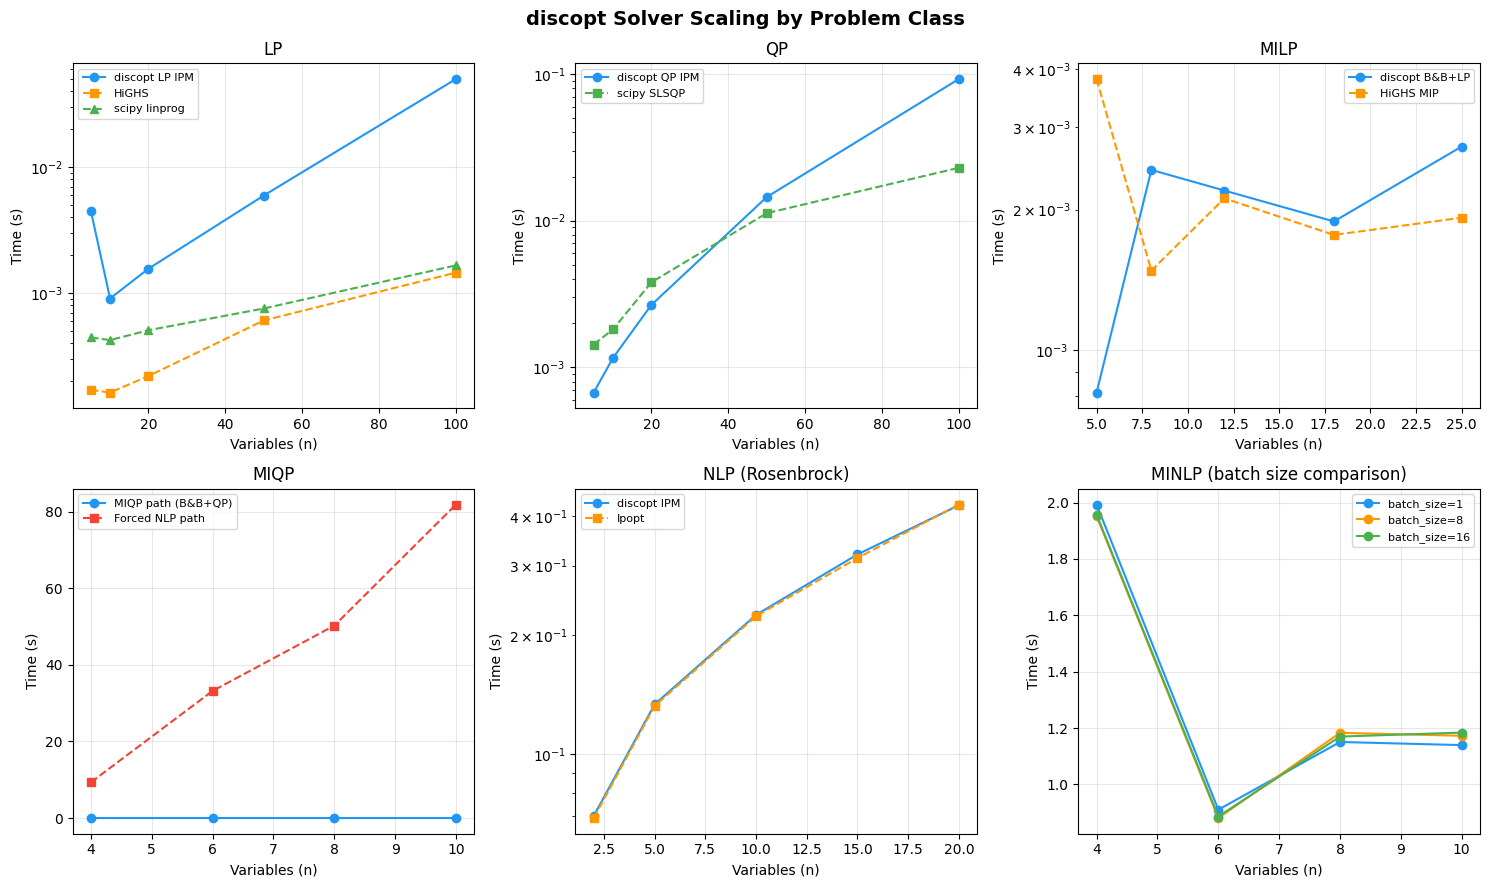

Plot saved to benchmarks_by_class.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("discopt Solver Scaling by Problem Class", fontsize=14, fontweight="bold")

# LP
ax = axes[0, 0]
ax.semilogy(lp_sizes, lp_results["discopt"], "o-", label="discopt LP IPM", color="#2196F3")
ax.semilogy(lp_sizes, lp_results["highs"], "s--", label="HiGHS", color="#FF9800")
ax.semilogy(lp_sizes, lp_results["scipy"], "^--", label="scipy linprog", color="#4CAF50")
ax.set_xlabel("Variables (n)")
ax.set_ylabel("Time (s)")
ax.set_title("LP")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# QP
ax = axes[0, 1]
ax.semilogy(qp_sizes, qp_results["discopt"], "o-", label="discopt QP IPM", color="#2196F3")
ax.semilogy(qp_sizes, qp_results["scipy"], "s--", label="scipy SLSQP", color="#4CAF50")
ax.set_xlabel("Variables (n)")
ax.set_ylabel("Time (s)")
ax.set_title("QP")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# MILP
ax = axes[0, 2]
ax.semilogy(milp_sizes, milp_results["discopt"], "o-", label="discopt B&B+LP", color="#2196F3")
ax.semilogy(milp_sizes, milp_results["highs"], "s--", label="HiGHS MIP", color="#FF9800")
ax.set_xlabel("Variables (n)")
ax.set_ylabel("Time (s)")
ax.set_title("MILP")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# MIQP
ax = axes[1, 0]
ax.plot(miqp_sizes, miqp_results["miqp_path"], "o-", label="MIQP path (B&B+QP)", color="#2196F3")
ax.plot(miqp_sizes, miqp_results["nlp_path"], "s--", label="Forced NLP path", color="#F44336")
ax.set_xlabel("Variables (n)")
ax.set_ylabel("Time (s)")
ax.set_title("MIQP")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# NLP
ax = axes[1, 1]
ax.semilogy(nlp_sizes, nlp_results["ipm"], "o-", label="discopt IPM", color="#2196F3")
if has_ipopt:
    ax.semilogy(nlp_sizes, nlp_results["ipopt"], "s--", label="Ipopt", color="#FF9800")
ax.set_xlabel("Variables (n)")
ax.set_ylabel("Time (s)")
ax.set_title("NLP (Rosenbrock)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# MINLP
ax = axes[1, 2]
colors_bs = ["#2196F3", "#FF9800", "#4CAF50"]
for idx, bs in enumerate(batch_sizes):
    ax.plot(
        minlp_sizes,
        minlp_results[f"batch={bs}"],
        "o-",
        label=f"batch_size={bs}",
        color=colors_bs[idx],
    )
ax.set_xlabel("Variables (n)")
ax.set_ylabel("Time (s)")
ax.set_title("MINLP (batch size comparison)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("benchmarks_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to benchmarks_by_class.png")

## Summary

Key observations:

- **LP/QP**: discopt's specialized IPM is competitive with HiGHS {cite:p}`Huangfu2018` and scipy for small-to-medium problems. HiGHS (C++ simplex) is faster for large LPs, as expected for a mature production solver.
- **MILP**: HiGHS MIP is significantly faster due to presolve, cutting planes, and decades of engineering. discopt's B&B+LP path {cite:p}`Land1960` is correct but not yet competitive on large instances.
- **MIQP**: The specialized MIQP path (B&B + QP relaxation) offers significant speedup over forcing the problem through the general NLP path.
- **NLP**: The pure-JAX IPM and Ipopt {cite:p}`Wachter2006` produce equivalent solutions. IPM benefits from JIT compilation for repeated solves.
- **MINLP**: Larger batch sizes improve throughput via JAX's vmap parallelism when the B&B tree has enough open nodes {cite:p}`Belotti2013`.

## References
